---
## Predicting Medical Insurance Cost
---
## Background
This study uses the **Medical Cost Personal Dataset**, a publicly available dataset hosted on Kaggle by Miri Choi. The dataset was adapted from the examples used in Brett Lantz's *Machine Learning with R*. The publisher cleaned and reformatted the original public-domain data to make it easier to use for machine learning and statistical analysis.

The dataset contains **1,338 observations** and **seven variables** describing demographic, health, lifestyle, and geographic characteristics of individuals in the United States. The objective is to predict each individual's **medical insurance charges** using personal attributes such as age, body mass index (BMI), smoking status, number of dependents, sex, and residential region.

The variables included in the dataset are:

| Variable     | Description                                                                                                  |
| ------------ | ------------------------------------------------------------------------------------------------------------ |
| **Age**      | Age of the primary insurance beneficiary.                                                                    |
| **Sex**      | Gender of the insurance beneficiary (male or female).                                                        |
| **BMI**      | Body Mass Index, calculated as weight (kg) divided by height squared (m²), used as an indicator of body fat. |
| **Children** | Number of dependents covered by the insurance policy.                                                        |
| **Smoker**   | Indicates whether the beneficiary is a smoker.                                                               |
| **Region**   | Residential region in the United States (northeast, northwest, southeast, southwest).                        |
| **Charges**  | Individual medical costs billed by the health insurance provider (target variable).                          |

---
### Dataset Characteristics

* **Source:** Kaggle – Medical Cost Personal Dataset
* **Number of observations:** 1,338
* **Number of features:** 6 predictor variables
* **Target variable:** Charges
* **Problem type:** Supervised Machine Learning (Regression)
* **Missing values:** None
* **Predictor types:**

  * Numerical: Age, BMI, Children
  * Categorical: Sex, Smoker, Region

---
## Recommended Business Questions for Exploratory Data Analysis  
• Are ages well represented in the data?<br>
• How is the BMI distributed?<br>
• How is gender (sex) distributed?<br>
• What is the proportion of smokers to non-smokers?<br>
• What is the distribution of Charges?<br>
• Does residency in certain regions affect medical insurance cost?<br>
• Does BMI category affect medical insurance cost?<br>
• Does smoking status influence medical insurance charges?<br>
• How are medical insurance charges distributed across age groups?<br>
• Do male and female policyholders incur differences in medical insurance charges?<br>
• Which age groups make up the largest share of policyholders in each region?<br>
• Which region has the highest typical medical insurance charges?<br>
• Is there a relationship between the number of children and medical insurance charges?<br>
• How does the distribution of BMI categories vary across different age groups?<br>
• How do average medical insurance charges differ between smokers and non-smokers across different age groups?<br>
• Does the impact of smoking on insurance charges vary by region?<br>
• Does smoking status influence insurance charges within each BMI category?<br>
• What are the overall characteristics and distribution of numeric variables in the data?<br>
• Which numerical variables are strongly associated with Charges?<br>
• What is the distribution of Categorical Variables<br>

---
## Notebook Contents
- Import Libraries
- Data Loading and Inspection
- Data Validation
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
  - Univariate Analysis
  - Bivariate Analysis
  - Multivariate Analysis
- Data Preprocessing
- Model Development
- Hyperparameter Tuning
- Model Evaluation
- SHAP Explainability
- Residual Analysis
- Actual vs Predicted Analysis


### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

sns.set()

import warnings
warnings.simplefilter("ignore", FutureWarning)

### Data Loading and Inspection

In [2]:
# Load the data
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# View Dataframe Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataframe has 1,338 rows of information contained in 7 seven columns.  
There are no missing values in the dataframe.  
All columns have information stored in the right data types.

## Data Validation

In [4]:
# Check for duplicates
df.duplicated().sum()

np.int64(1)

## Data Cleaning

In [5]:
# Drop duplicates
df.drop_duplicates(inplace= True)

In [6]:
# Express charges to 2 decimal places as currency values should
df["charges"] = df.charges.round(2)

## Feature Engineering (for EDA only)

In [7]:
# Create age_group column
bins = [18, 25, 35, 45, 55, 65]

labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

In [8]:
# Create bmi_category column
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])

The columns created above are meant to aid the data exploration phase alone.

## Exploratory Data Analysis

## Univariate Analysis

### ➤ How is Age distributed?

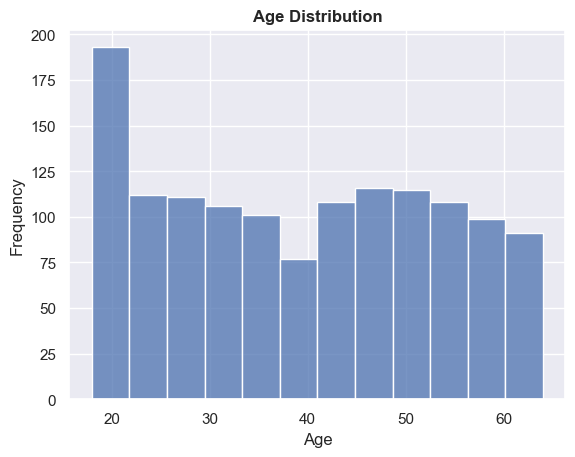

In [9]:
# Histogram of age
sns.histplot(df["age"])

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution", fontweight= "bold")

plt.show()

### Insight:
* The histogram of policyholders' ages shows that all ages are fairly represented.<br>
* With the minimum age being `18`, all records are of adults.<br>
* The first bar (approximate age of `18-22`) is the most represented, while the sixth bar<b<br>
  (approvimate age of `38-42`) is the least represented. This implies that the data<br>
  is characterised by young people mostly.<br>
* The other age groups show similar representatio with moderate fluctuations.

### ➤ How is BMI distributed?

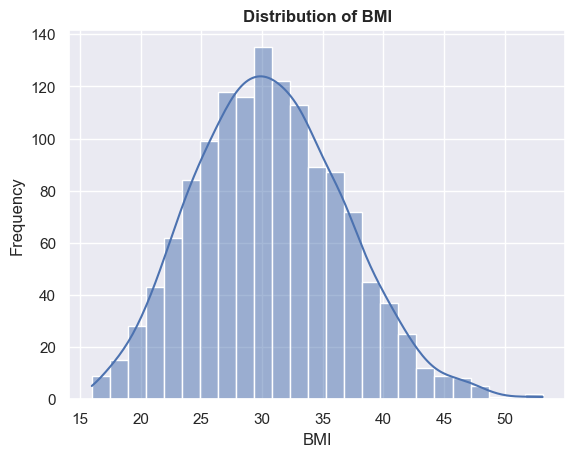

In [10]:
# Histogram of BMI
sns.histplot(df["bmi"], kde= True)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Distribution of BMI", fontweight= "bold")

plt.show()

### Insight:  
The distribution of bmi is about normal with all values fairly represented since the<br>
histogram is almost perfectly bell-shaped. The BMI ranges from `16` to `53`.

### ➤ How is Gender distributed?

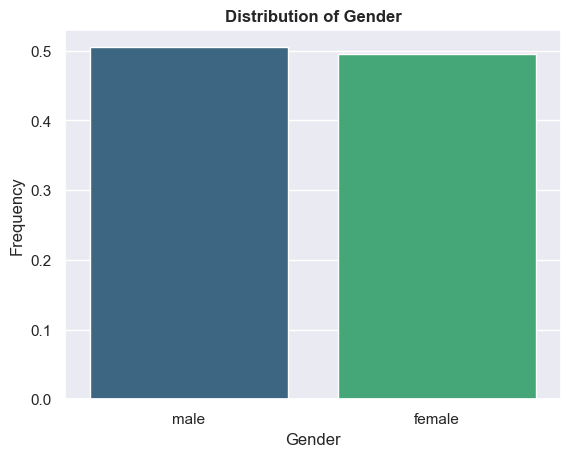

In [11]:
# Bar chart os Gender
sex = df["sex"].value_counts(normalize= True)
sns.barplot(x= sex.index, y= sex.values, palette= "viridis")

plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.title("Distribution of Gender", fontweight= "bold")

plt.show()

### Insight:  
Sex categories are fairly balanced with male-to-female ratio of `50.5:49.5`

### ➤ What is the proportion of smokers and non-smokers?

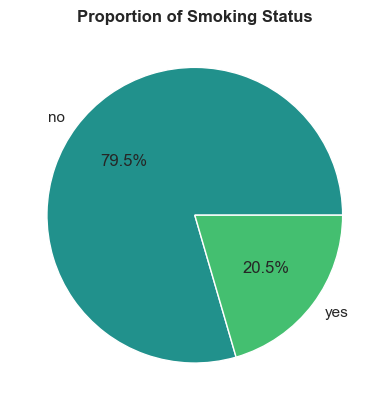

In [12]:
# Pie chart of smoker status
smoker = df["smoker"].value_counts()

cmap = plt.colormaps["viridis"]

colors = [cmap(0.5), cmap(0.7)]
plt.pie(smoker.values, labels= smoker.index, autopct="%1.1f%%", colors=colors)
plt.title("Proportion of Smoking Status", fontweight= "bold")
plt.show()

### Insight:  
The majority smoker class is the begative class which contitutes about<br>
`79.5%` of policyholders.

### ➤ What is the distribution of Charges?

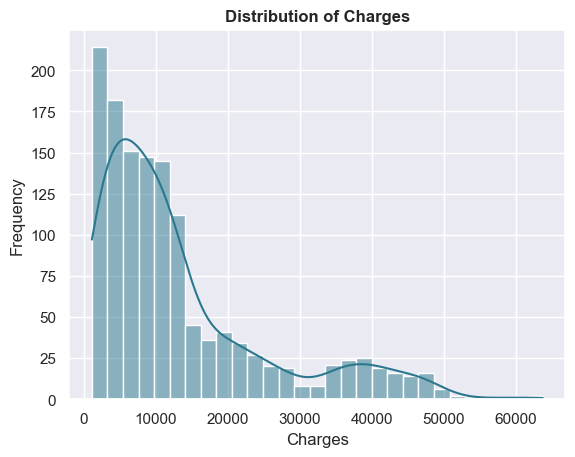

In [13]:
# Histogram of Charges
cmap = plt.colormaps["viridis"]
sns.histplot(df["charges"], kde= True, color= cmap(0.4))

plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Charges", fontweight= "bold")

plt.show()

### Insights:  
* The distribution of charges is right-skewed.  
* This shows that most policyholders subscribed to cheaper policies with very few subscribed<br>
  to more expensive policies.

## Bivariate Analysis

### ➤ Does residency in certain regions affect medical insurance costs?

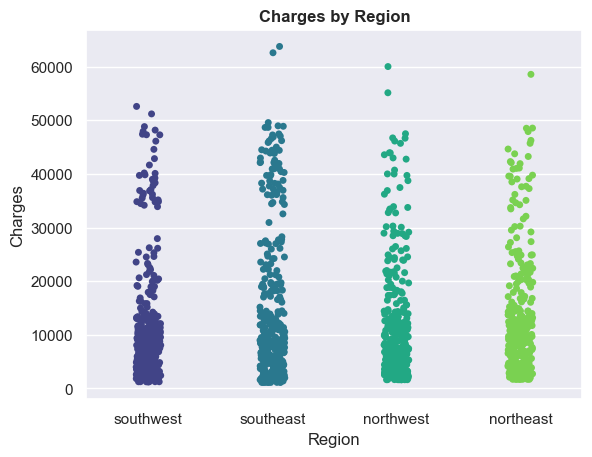

In [14]:
# Strip plot of Charges by Region
sns.stripplot(data= df, x= "region", y= "charges", palette= "viridis")

plt.xlabel("Region")
plt.ylabel("Charges")
plt.title("Charges by Region", fontweight= "bold")

plt.show()

### Insights:  
The chart above shows that 
- most residents of all the regions covered by this data subscribed to low charge policies<br>
  as seen by the heavily clustered data points at the base of each region's strip plot.  
- a moderate number of residents across all regions subscribed to medium charge policies which<br>
  is evident in the scattered data points for every region.
- very few residents across all regions are subscribed to premium charge policies.<br>
- In summary, region alone does not affect charges.

### ➤ Does BMI category affect medical insurance cost?

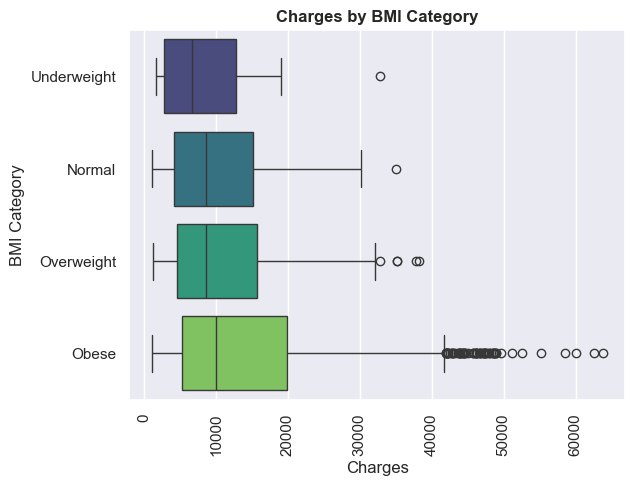

In [15]:
# Box plot of Charges by BMI Category
sns.boxplot(data= df, x= "charges", y= "bmi_category", palette= "viridis")

plt.xlabel("Charges")
plt.xticks(rotation= 90)
plt.ylabel("BMI Category")
plt.title("Charges by BMI Category", fontweight= "bold")

plt.show()

### Insights:  
* The box plot above reveals that the underweight BMI category has the least median value of charges,<br>
  while the Obese category has the highest median value. The Normal and Overweight categories have similar median values.<br>
* While the other BMI categories have very few outlier values in the medium charges range, the Obese category has many<br>
  outlier values in the premium charges range.<br>
* The Obese category has a wider box than the other three categories which indicates a wider range of charges than with<br>
  the other three categories.  
* The trend in BMI category is quite similar to the trend revealed by the histogram of Charges which suggests that BMI<br>
  (the basis for BMI category) might be a strong predictor of Charges.

### ➤ How are medical insurance charges distributed across age groups?

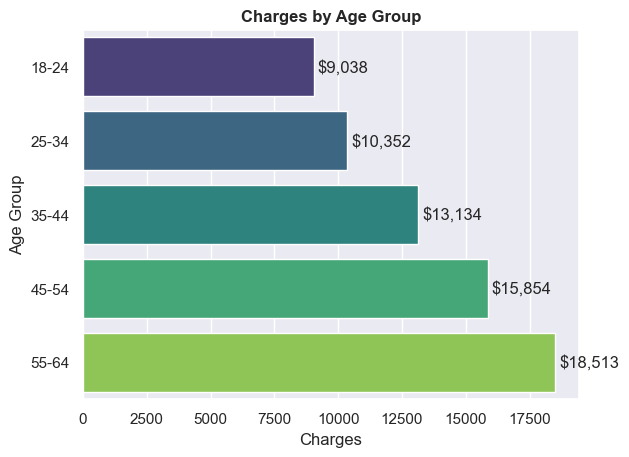

In [16]:
# Bar plot of Charges by Age Group
ax = sns.barplot(data= df,
                 x= "charges",
                 y= "age_group",
                 errorbar= None,
                 palette= "viridis")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="${:,.0f}",
        padding=3
    )
    
plt.xlabel("Charges")
plt.ylabel("Age Group")
plt.title("Charges by Age Group", fontweight= "bold")

plt.show()

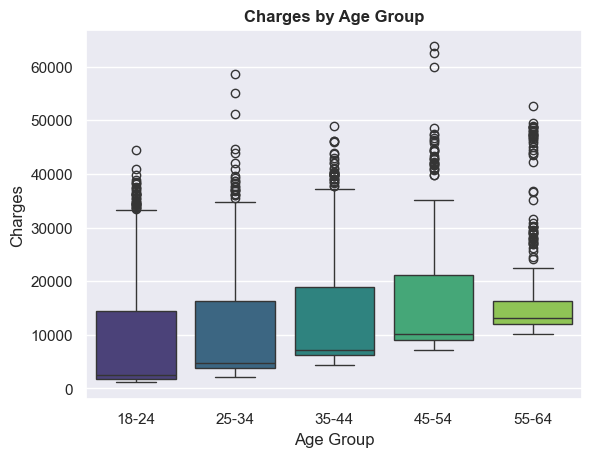

In [17]:
# Box plot of Charges by Age Group
sns.boxplot(data=df, x="age_group", y="charges", palette= "viridis")

plt.xlabel("Age Group")
plt.ylabel("Charges")
plt.title("Charges by Age Group", fontweight= "bold")

plt.show()

### Insights:  
* The bar chart above shows that average insurance charges increases with age (the base variable for age_group), while<br>
  the box plot shows the variability of medical insurance charges across age groups.<br>
* Both charts show that the older a policyholder gets, the higher their likelihood of incurring higher medical insurance costs.<br>
* While the average insurance cost keeps increasing from one age group to another, the increment is more noticeable from<br>
  `35-44` onwards.<br>
* Charges across age groups are positively skewed similar to the histogram plot of Charges, which shows that age could be<br>
  a major predictor of Charges.

### ➤ Do male and female policyholders incur different medical insurance charges?

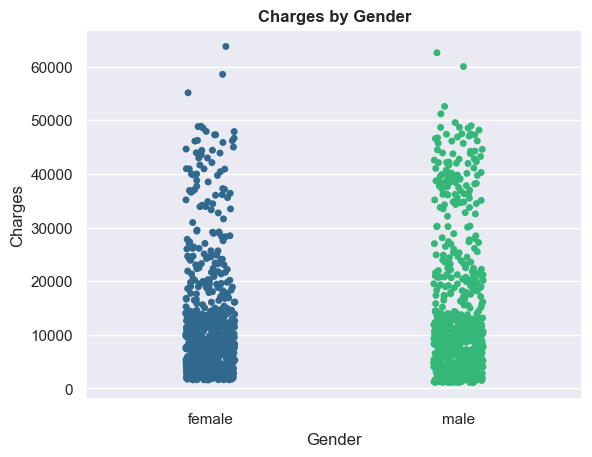

In [18]:
# Strip plot of Charges by Gender
sns.stripplot(data= df, x= "sex", y= "charges", palette= "viridis")

plt.xlabel("Gender")
plt.ylabel("Charges")
plt.title("Charges by Gender", fontweight= "bold")

plt.show()

### Insights:
* From the heavy clusters at the base, to the sparse clusters in the middle, to the scarce<br>
  data points at the top, the distribution of Charges for both genders are very similar.
* The lack of variability in the distribution by gender tends to imply that it might be a<br>
  weak predictor of medical insurance costs.

### ➤ Which age groups make up the largest share of policyholders in each region?

In [19]:
pd.crosstab(df["region"], df["age_group"])

age_group,18-24,25-34,35-44,45-54,55-64
region,,,,,
northeast,66,65,63,71,59
northwest,68,65,63,69,59
southeast,77,75,72,76,64
southwest,66,66,62,71,60


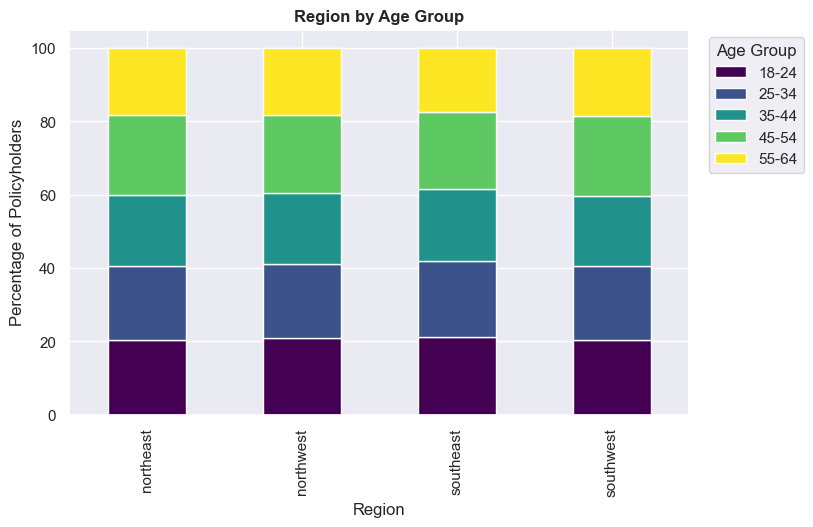

In [20]:
# Frequency table of policyholders by Region and Age Group
reg_a = pd.crosstab(df["region"], df["age_group"])

# Stacked Bar chart of Age Group by Region
ax = (reg_a.div(reg_a.sum(axis=1), axis=0) * 100).plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    figsize=(8, 5)
)

plt.xlabel("Region")
plt.ylabel("Percentage of Policyholders")
ax.set_ylabel("Percentage of Policyholders")
plt.title("Region by Age Group", fontweight= "bold")
ax.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

### Insights:  
* The age composition across all regions is remarkably consistent. This shows that all regions were equally represented.  
* There was no dominant age group across regions.  
* In all, regional differences in medical insurance costs cannot be explained by age.

### ➤ Which region has the highest typical medical insurance charges?

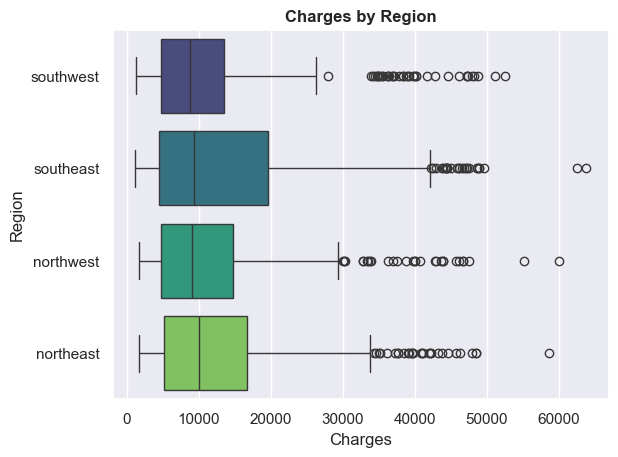

In [21]:
# Box plot of Charges by Region
sns.boxplot(data= df, x= "charges", y= "region", palette= "viridis")

plt.xlabel("Charges")
plt.ylabel("Region")
plt.title("Charges by Region", fontweight= "bold")

plt.show()

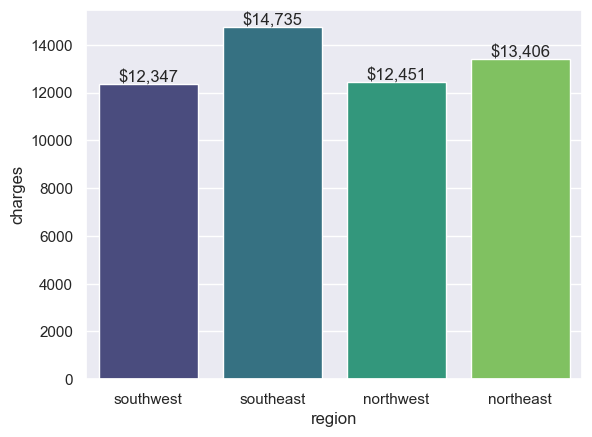

In [22]:
ax = sns.barplot(
    data=df,
    x="region",
    y="charges",
    errorbar= None,
    palette= "viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt="${:,.0f}")

### Insights:  
* Like the histogram of Charges plotted earlier, all the regions above are right-skewed with high outlier values.  
* The median Charges value for all regions are quite close. This suggests that there are very little dissimilarities<br>
  in Charges across regions.  
* There is an overlap of box plots which implies that region might be a weak predictor of medical insurance costs.

### ➤ Is there a relationship between the number of children and medical insurance charges?

In [23]:
# Count of policyholders by number of children
df["children"].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

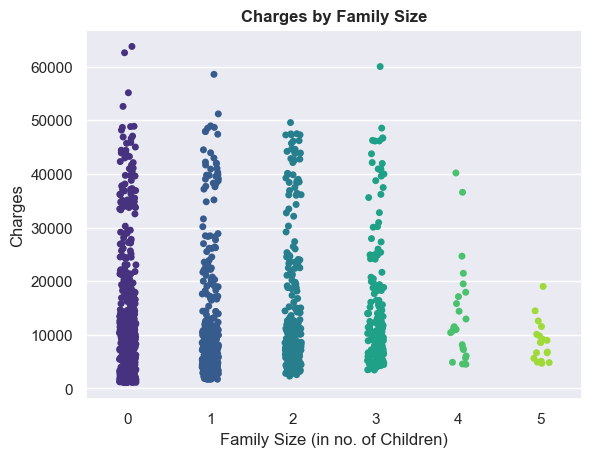

In [24]:
# Strip plot of Charges by Family Size
sns.stripplot(data= df, x= "children", y= "charges", palette= "viridis")

plt.xlabel("Family Size (in no. of Children)")
plt.ylabel("Charges")
plt.title("Charges by Family Size", fontweight= "bold")

plt.show()

### Insights:  
* The plot above shows that a large number of policyholders have between `0 - 3` children, with very<br>
  few other having `4` and `5` children. This explains why the variability of Charges for people with<br>
  smaller family size is far more than those with larger family sizes.  
* Due to the huge class imbalance, no strong pattern is evident, thus, making family size a very<br>
  weak predictor of Charges.

### ➤ Does smoking status influence medical insurance charges?

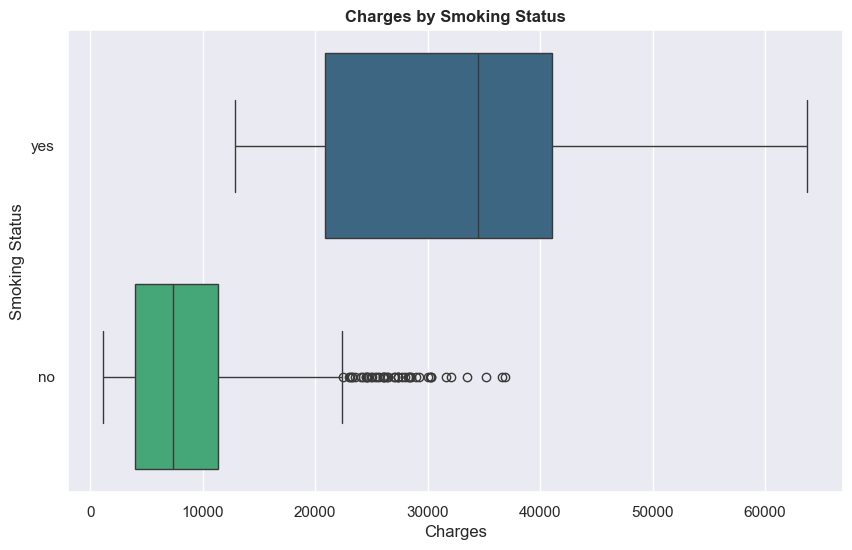

In [25]:
# Strip plot of Charges by Smoking status
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="charges",
    y="smoker",
    palette="viridis",
    ax=ax
)

plt.xlabel("Charges")
plt.ylabel("Smoking Status")
plt.title("Charges by Smoking Status", fontweight= "bold")

plt.show()

### Insights:<br>
* The box size for smokers is much larger than the one for non-smokers.<br>
  The box for smokers is far more to the right. While the median Charges for non-smokers is about `$7,000`, it is about<br>
  `$34,000` for smokers. That tells us that smokers incur almost five times the Charges that non-smokers incur.<br>
* The box for smokers is much wider than for non-smokers. In other words, the difference in lower- to higher-cost smokers is much<br>
  higher than the difference for non-smokers. This makes the smoker group a risk to insurers.<br>
* The box plot also shows some outliers. This indicates a small group of non-smokers that are either old, over-weight or obese,<br>
  have more than one children, require expensive treatments, or have a combination of these factors.

### ➤ How does the distribution of BMI categories vary across different age groups?

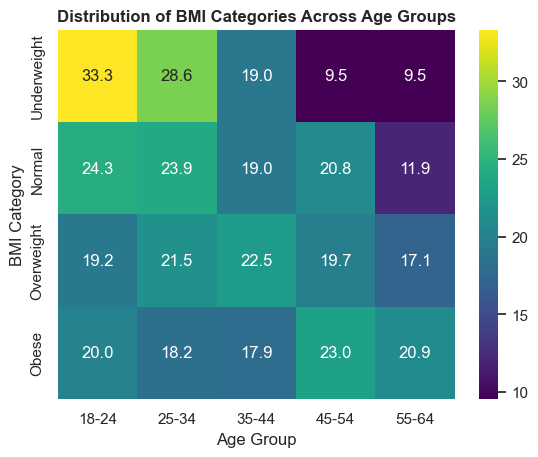

In [26]:
# Frequency table of policyholders by BMI Category and Age Group
bmi_age = pd.crosstab(
    df["bmi_category"],
    df["age_group"],
    normalize="index"
) * 100

# Heatmap of BMI Category by Age Group
sns.heatmap(
    bmi_age,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.xlabel("Age Group")
plt.ylabel("BMI Category")
plt.title("Distribution of BMI Categories Across Age Groups", fontweight= "bold")

plt.show()

### Insights:  
* Young people between ages `18-24` are most likely to be under-weight by `33.3%`, and<br>
  the likelihood decreases with each age group to `9.5%` for the last two age groups.  
* The proportion of obese people is highest for the `45-54` age group with significant<br>
  proportions in the `55-64` and `18-24` age groups.  
* The percentages of normal and overweight individuals remain relatively stable across<br>
  age groups, indicating a gradual shift from underweight to higher BMI categories as policyholders get older.

## Multivariate Analysis

### ➤ How do average medical insurance charges differ between smokers and non-smokers across different age groups?

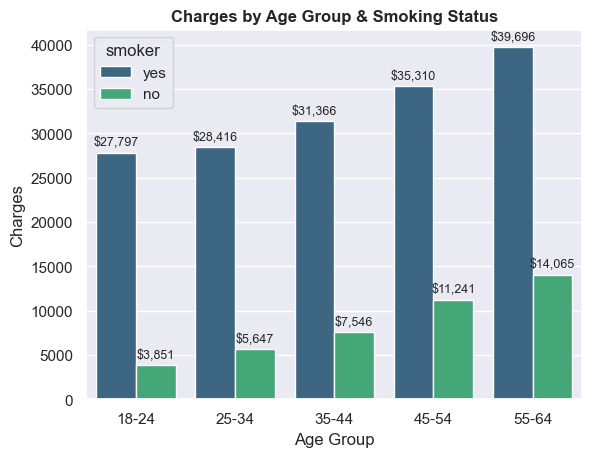

In [27]:
# Bar plot of Charges by Age Group and Smoking Status
ax = (
    sns.barplot(data= df,
                x= "age_group",
                y= "charges",
                hue= "smoker",
                errorbar= None,
                palette= "viridis")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="${:,.0f}",
        padding=3,
        fontsize=9
    )

plt.xlabel("Age Group")
plt.ylabel("Charges")
plt.title("Charges by Age Group & Smoking Status", fontweight= "bold")

plt.show()

### Insights:  
* The bar chart above shows that average Charges increases with age group for smokers and non-smokers.  
* However, the average Charges is significantly higher for smokers than for non-smokers.  
* In summary, medical insurance cost is much higher for smokers the older they get than for non-smoking youths.

### ➤ Does the impact of smoking on insurance charges vary by region?

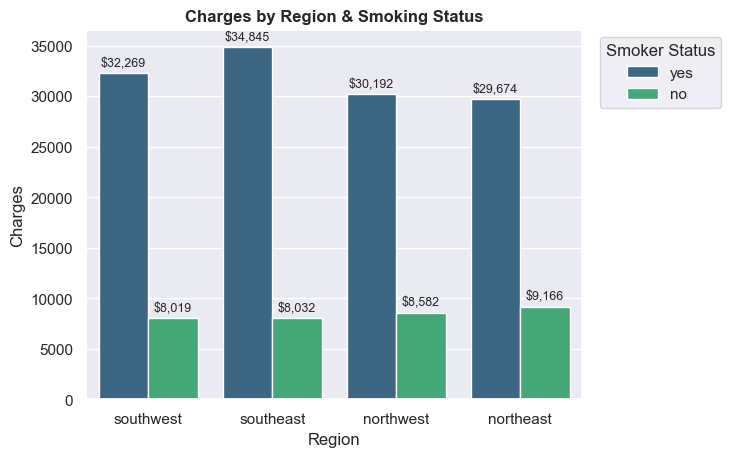

In [28]:
# Bar plot of Charges by Region and Smoking Status
ax = (
    sns.barplot(
        data= df,
        x= "region",
        y= "charges",
        hue= "smoker",
        errorbar= None,
        palette= "viridis"
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="${:,.0f}",
        padding=3,
        fontsize=9
    )

plt.xlabel("Region")
plt.ylabel("Charges")
plt.title("Charges by Region & Smoking Status", fontweight= "bold")
ax.legend(
    title="Smoker Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

### Insights:  
* Non-smokers resident in North-East region tend to incur the highest medical insurance cost than non-smokers in other regions.  
* While it has already been established that smokers incur higher medical insurance costs than non-smokers, smokers resident<br>
  in the South-East region incur the highest medical insurance cost than smokers resident in other regions.

### ➤ Does smoking status influence insurance charges within each BMI category?

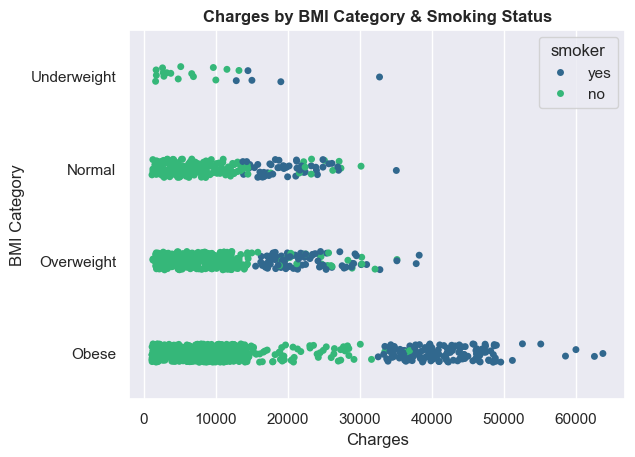

In [29]:
# Strip plot of Charges by BMI Category and Smoking Status
sns.stripplot(
    data= df,
    x= "charges",
    y= "bmi_category",
    hue= "smoker",
    palette= "viridis"
)

plt.xlabel("Charges")
plt.ylabel("BMI Category")
plt.title("Charges by BMI Category & Smoking Status", fontweight= "bold")

plt.show()

### Insights:  
From the strip plot above, smokers across BMI Categories typically incur higher medical insurance cost<br>
than non-smokers. Over all, Obese policyholders incur the highest higher  costs than other BMI Categories<br>
while Under-weight BMI Category policyholders incur the least cost.

### ➤ What are the overall characteristics and distribution of numerical variables in the data?

In [30]:
df.describe(include= "number").round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


### ➤ Which numerical variables are strongly associated with Charges?

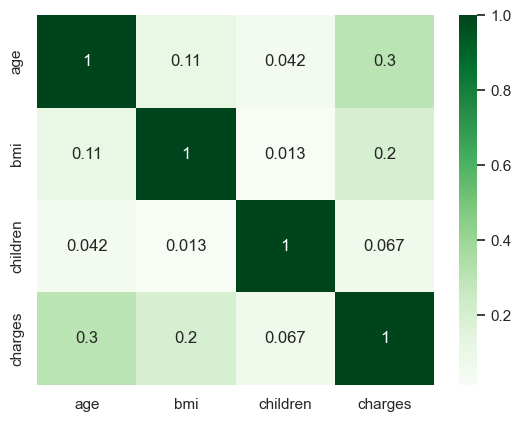

In [31]:
numeric = df.select_dtypes(include= "number")
num_corr = numeric.corr()
sns.heatmap(num_corr, annot= True, cmap= "Greens");

### Insights:  
* There is no negative correlation between numeric columns.  
* The strongest correlation value is observed between Age and Charges, yet it is weak.  
* The correlation between BMI and Charges comes in next, and even that is weaker.  
* The weakest yet is number of Children.  
* The correlation coefficient between Age, BMI, Children, and Charges<br>
  seem to imply that the higher the variables, the higher the Charges. However,<br>
  their respective correlation coefficients show that their respective impact values<br>
  would be too low for any of them to significantly impact Charges.

### ➤ What is the distribution of Categorical Variables

In [32]:
df.describe(include= ["object", "category"])

,sex,smoker,region,age_group,bmi_category
count,1337,1337,1337,1337,1337
unique,2,2,4,5,4
top,male,no,southeast,45-54,Obese
freq,675,1063,364,287,704


### Insights:  
The descriptive statistics for categorical columns above shows that  
- there are 1,337 records across columns.
- more than half of the gender data values belong to male category.
- 1,063 of policyholders are non-smokers.
- more than `25%` of policyholders reside in the South-East region.
- over `20%` of policyholders are between the ages of `45-54`.
- more than `50%` of policyholders are obese.

## Feature - Target Split

In [33]:
# Create target vector y
target = "charges"
y= df[target].copy()

In [34]:
# Create feature matrix X
X = df.drop(
    columns= [
    "age_group",
    "bmi_category",
    "charges"
    ]
).copy()

NOTE:  
Age Group and BMI Category were dropped since they contain information  
related to other features (`age` and `bmi`).

In [35]:
# Get categorical and numerical columns

# Change object data type to category for models that process categorical data natively
cats = X.select_dtypes(include= "object").columns.to_list()
for col in cats:
    X[col] = X[col].astype("category")

nums = X.select_dtypes(include= "number").columns.to_list()

## Train - Test Split

In [36]:
# Split feature matrix and target vector into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

## Data Preprocessing

In [37]:
# Pre-processing for linear models
scaled = ColumnTransformer([
    ("nums", StandardScaler(), nums),
    ("cats", OneHotEncoder(drop="first",
                           handle_unknown="ignore",
                           sparse_output=False), cats)
])

In [38]:
# Pre-processing for tree models that require numeric inputs
unscaled = ColumnTransformer([
    ("nums", "passthrough", nums),
    ("cats", OneHotEncoder(drop="first",
                           handle_unknown="ignore",
                           sparse_output=False), cats)
])

In [39]:
# Pre-processing for native categorical models
native = ColumnTransformer([
    ("nums", "passthrough", nums),
    ("cats", "passthrough", cats)
])

## Model Development

In [40]:
# Dictionary of models
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", scaled),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("preprocessor", scaled),
        ("model", Ridge())
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", unscaled),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", unscaled),
        ("model", ExtraTreesRegressor(
            random_state=42
        ))
    ]),

    "LightGBM": LGBMRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        enable_categorical=True,
        tree_method="hist"
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0
    )

}

## Train, Fit, and Evaluate all Models

In [41]:
# Create evaluate models function
def evaluate_models(
    models,
    X_train,
    X_test,
    y_train,
    y_test,
    cat_features=None
):
    """
    Train and evaluate multiple regression models.
    """

    results = []

    for name, model in models.items():

        print(f"Training {name}...")

        # Specific setup for CatBoost model to process 
        # categorical features during fit()
        if isinstance(model, CatBoostRegressor):
            model.fit(
                X_train,
                y_train,
                cat_features=cat_features
            )

        else:
            model.fit(
                X_train,
                y_train
            )

        # Prediction
        y_pred = model.predict(X_test)

        # Regression model metrics for evaluation
        results.append({
            "Model": name,
            "MAE": round(
                mean_absolute_error(y_test, y_pred),
                4
            ),
            "RMSE": round(
                root_mean_squared_error(y_test, y_pred),
                4
            ),
            "R2": round(
                r2_score(y_test, y_pred),
                4
            )
        })

    return (
        pd.DataFrame(results)
        .sort_values(
            by="R2",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [42]:
# Apply evaluate model function
results = evaluate_models(
    models=models,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    cat_features=cats
)
print()
results

Training Linear Regression...
Training Ridge...
Training Random Forest...
Training Extra Trees...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score 13030.203365
Training XGBoost...
Training CatBoost...



,Model,MAE,RMSE,R2
0,CatBoost,2602.3186,4454.2772,0.8920
1,LightGBM,2824.8886,4583.8857,0.8857
2,Random Forest,2632.8590,4694.6310,0.8801
3,XGBoost,3024.1363,5186.4578,0.8536
4,Extra Trees,2693.2126,5196.7979,0.8530
5,Linear Regression,4177.0458,5956.3430,0.8069
6,Ridge,4193.8922,5971.8618,0.8059


### Insights:  
The top 5 models are tree models. Typically, tree models perform better  
than linear models especially in situations where some features exhibit  
non-linear relationships with the target variable. So, it is not much  
of a surprise that tree models have performed better.

## Hyperparameter Tuning

In [43]:
# Create tune top models function
def tune_top_models(
    results,
    models,
    param_grids,
    X_train,
    y_train,
    cat_features=None,
    metric="R2",
    top_n=5,
    scoring="r2",
    cv=5,
    n_jobs=-1
):
    """
    Select the top 5 performing models and perform GridSearchCV.
    """

    tuned_models = {}

    top_model_names = (
        results
        .sort_values(by=metric, ascending=False)
        .head(top_n)["Model"]
        .tolist()
    )

    print("Selected Models:")
    print(top_model_names)
    print()

    for name in top_model_names:

        print(f"Tuning {name}...")

        model = models[name]

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=1
        )

        if isinstance(model, CatBoostRegressor):
            grid.fit(
                X_train,
                y_train,
                cat_features=cat_features
            )

        else:
            grid.fit(
                X_train,
                y_train
            )

        tuned_models[name] = grid

    return tuned_models

In [44]:
# Hyperparameter grids for model tuning
param_grids = {

    "Linear Regression": {},

    "Ridge": {
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

    "Extra Trees": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [31, 50],
        "max_depth": [-1, 10]
    },

    "XGBoost": {
        "n_estimators": [200, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [4, 6, 8],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },

    "CatBoost": {
        "iterations": [200, 500],
        "learning_rate": [0.01, 0.05, 0.1],
        "depth": [4, 6, 8],
        "l2_leaf_reg": [3, 5, 7]
    }

}

In [45]:
# Run tune top models
tuned_models = tune_top_models(
    results=results,
    models=models,
    param_grids=param_grids,
    X_train=X_train,
    y_train=y_train,
    cat_features=cats,
    top_n=5
)


Selected Models:
['CatBoost', 'LightGBM', 'Random Forest', 'XGBoost', 'Extra Trees']

Tuning CatBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Tuning LightGBM...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score 13030.203365
Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tuning XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tuning Extra Trees...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [46]:
# Create dataframe of metrics after jyper-parameter tuning
summary = []

for model_name, grid in tuned_models.items():
    summary.append({
        "Model": model_name,
        "Best CV R2": grid.best_score_,
        "Best Parameters": grid.best_params_,
        "Best Estimator": type(grid.best_estimator_).__name__
    })

tuning_results = pd.DataFrame(summary)

tuning_results

,Model,Best CV R2,Best Parameters,Best Estimator
0,CatBoost,0.847565,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':...",CatBoostRegressor
1,LightGBM,0.830542,"{'learning_rate': 0.01, 'max_depth': -1, 'n_es...",LGBMRegressor
2,Random Forest,0.830242,"{'model__max_depth': 10, 'model__min_samples_l...",Pipeline
3,XGBoost,0.842897,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",XGBRegressor
4,Extra Trees,0.834129,"{'model__max_depth': 10, 'model__min_samples_l...",Pipeline


In [47]:
# Create evaluate_tuned_models function
def evaluate_tuned_models(
    tuned_models,
    X_test,
    y_test
):

    results = []

    for name, grid in tuned_models.items():

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test)

        results.append({

            "Model": name,

            "MAE": round(
                mean_absolute_error(y_test, y_pred),
                2
            ),

            "RMSE": round(
                np.sqrt(
                    mean_squared_error(y_test, y_pred)
                ),
                2
            ),

            "R2": round(
                r2_score(y_test, y_pred),
                4
            ),

            "Best CV Score": round(
                grid.best_score_,
                4
            ),

            "Best Parameters": grid.best_params_

        })

    return (
        pd.DataFrame(results)
        .sort_values("R2", ascending=False)
        .reset_index(drop=True)
    )

In [48]:
# Apply evaluate_tuned_models function
tuned_results = evaluate_tuned_models(
    tuned_models,
    X_test,
    y_test
)

tuned_results

,Model,MAE,RMSE,R2,Best CV Score,Best Parameters
0,XGBoost,2420.69,4222.06,0.9030,0.8429,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
1,CatBoost,2443.27,4250.01,0.9017,0.8476,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':..."
2,Random Forest,2524.57,4463.77,0.8916,0.8302,"{'model__max_depth': 10, 'model__min_samples_l..."
3,Extra Trees,2393.09,4462.56,0.8916,0.8341,"{'model__max_depth': 10, 'model__min_samples_l..."
4,LightGBM,2631.85,4464.65,0.8915,0.8305,"{'learning_rate': 0.01, 'max_depth': -1, 'n_es..."


## Compare Baseline and Tuned Models

In [49]:
# Create compare models function
def compare_models(
    baseline_results,
    tuned_results
):
    """
    Compare performances between baseline and tuned models.
    """

    comparison = (
        baseline_results[["Model", "MAE", "RMSE", "R2"]]
        .merge(
            tuned_results[["Model", "MAE", "RMSE", "R2"]],
            on="Model",
            suffixes=("_Baseline", "_Tuned")
        )
    )

    comparison["R2 Improvement"] = (
        comparison["R2_Tuned"] -
        comparison["R2_Baseline"]
    ).round(4)

    comparison["RMSE Improvement"] = (
        comparison["RMSE_Baseline"] -
        comparison["RMSE_Tuned"]
    ).round(2)

    comparison["MAE Improvement"] = (
        comparison["MAE_Baseline"] -
        comparison["MAE_Tuned"]
    ).round(2)

    return comparison

In [50]:
# Run compare models function
comparison = compare_models(
    results,
    tuned_results
)

comparison

,Model,MAE_Baseline,RMSE_Baseline,R2_Baseline,MAE_Tuned,RMSE_Tuned,R2_Tuned,R2 Improvement,RMSE Improvement,MAE Improvement
0,CatBoost,2602.3186,4454.2772,0.8920,2443.27,4250.01,0.9017,0.0097,204.27,159.05
1,LightGBM,2824.8886,4583.8857,0.8857,2631.85,4464.65,0.8915,0.0058,119.24,193.04
2,Random Forest,2632.8590,4694.6310,0.8801,2524.57,4463.77,0.8916,0.0115,230.86,108.29
3,XGBoost,3024.1363,5186.4578,0.8536,2420.69,4222.06,0.9030,0.0494,964.40,603.45
4,Extra Trees,2693.2126,5196.7979,0.8530,2393.09,4462.56,0.8916,0.0386,734.24,300.12


## Get the Best Model

In [51]:
# Create get best model function
def get_best_model(
    tuned_models,
    tuned_results,
    metric="R2"
):
    """
    Returns the best fitted model.
    """

    best_model_name = (
        tuned_results
        .sort_values(metric, ascending=False)
        .iloc[0]["Model"]
    )

    print(f"Best Model: {best_model_name}")

    return (
        best_model_name,
        tuned_models[best_model_name].best_estimator_
    )

In [52]:
best_model_name, best_model = get_best_model(
    tuned_models,
    tuned_results
)

Best Model: XGBoost


## Get Feature Importance

In [53]:
# Create get feature importance function
def get_feature_importance(model, X_train, top_n=None):
    """
    Return a DataFrame of feature importance.
    """

    # Pipeline models
    if isinstance(model, Pipeline):
        preprocessor = model.named_steps["preprocessor"]
        estimator = model.named_steps["model"]

        feature_names = preprocessor.get_feature_names_out()
        importances = estimator.feature_importances_

    # Native models
    else:
        feature_names = X_train.columns
        importances = model.feature_importances_

    importance = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    if top_n is not None:
        importance = importance.head(top_n)

    return importance

In [54]:
# Get geature importance
importance = get_feature_importance(
    best_model,
    X_train,
    top_n=15
)
importance

,Feature,Importance
4,smoker,0.902094
2,bmi,0.046872
0,age,0.033538
3,children,0.009139
5,region,0.004840
1,sex,0.003516


## Plot Feature Importance

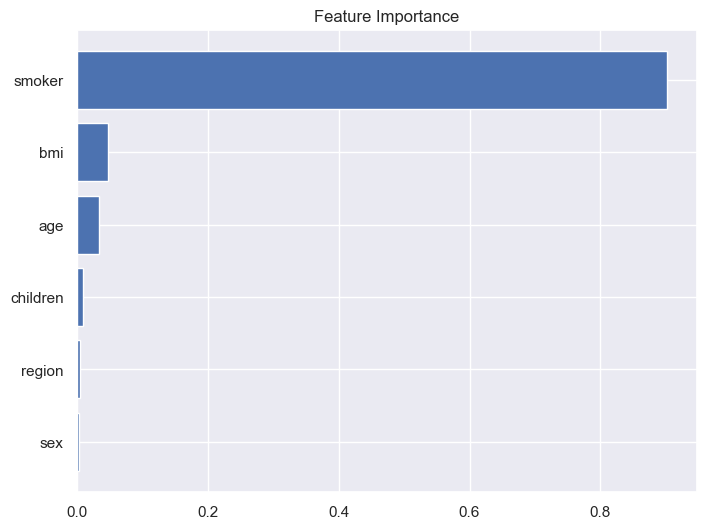

In [55]:
# Create a feature importance plot
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Feature Importance")

plt.show()
   

### Insights:  
* The chart of feature importance above shows that the model heavily relies on smoking status in order
  to make predictions.
* BMI and Age come in at distant second and third most important features by `4.7%` and `3.3%` respectively.
* Features following by very low percentages are Children, Region, and Sex.
 
  While feature importance highlights features by their relevance, it does not tell the extent to which each feature
  affects the model. To uncover the magnitude of effects of each feature, we must look to SHAP values for some
explanations.

## Get SHAP Values

In [56]:
# Create a SHAP explainer object
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for every observation in the test set
shap_values = explainer(X_test)

## SHAP Values Plot

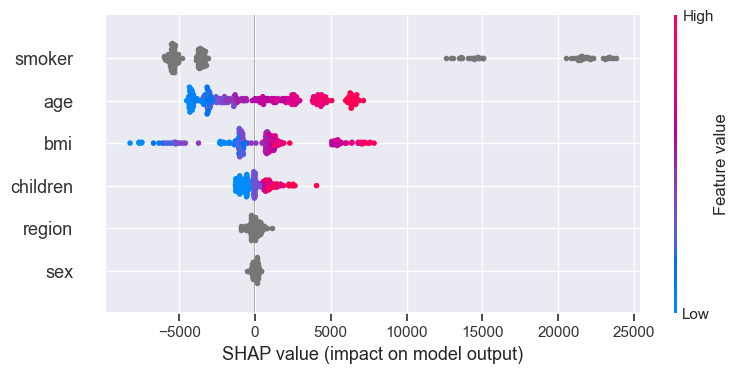

In [57]:
# Create beeswarm plot of SHAP values
shap.summary_plot(shap_values, X_test)

### Insights:  
* The colored swarms are for numeric features while the gray swarms are for categorical features.
* **Smoking status** significantly affects **Charges**. While the negative category **(non-smokers)** significantly reduces
  predicted **Charges**, the positive category **(smokers)** also significantly increases predicted **Charges** as reflected
  in the swarms on both the left hand and the right hand sides.
* For the **Age** feature, as one gets older, their predicted **Charges** increases by a relatively low amount and vice versa.
  This means that a very young medical insurance policyholder would get a slightly reduced predicted **Charges** amount than
  a much older person who would get a slight increase in their predicted **Charges**.
* **BMI** also trends in a similar way as **Age**. The larger a policyholder's **BMI** value, the more expensive their **Charges**
  becomes and vice versa. If a policyholder's **BMI** is on the low range, their predicted **Charges** reduces slightly.
* Even though it was shown in the exploratory data analysis section that the **Children** feature has a non-linear relationship
  with **Charges**, the SHAP plot shows that lower **Children** values tend to lower **Charges** and vice versa. The
  effect is even much smaller as seen in the feature importance. In other words, smaller **Children** values tend to insignificantly
  reduce **Charges**, while larger **Children** values tend to insignificantly increase **Charges** values.
* **Region** and **Sex** have their points cluster around zero. This means that they provide very little predictive value to the model.
  Information about one's residential location and gender impact the target variable very insignificantly.

## Waterfall Plot Of A Unique Case

In [58]:
# Compute residual values
predictions = best_model.predict(X_test)
residuals = y_test - predictions

In [59]:
# Observation with the largest absolute error
outlier = np.abs(residuals).argmax()

outlier

np.int64(124)

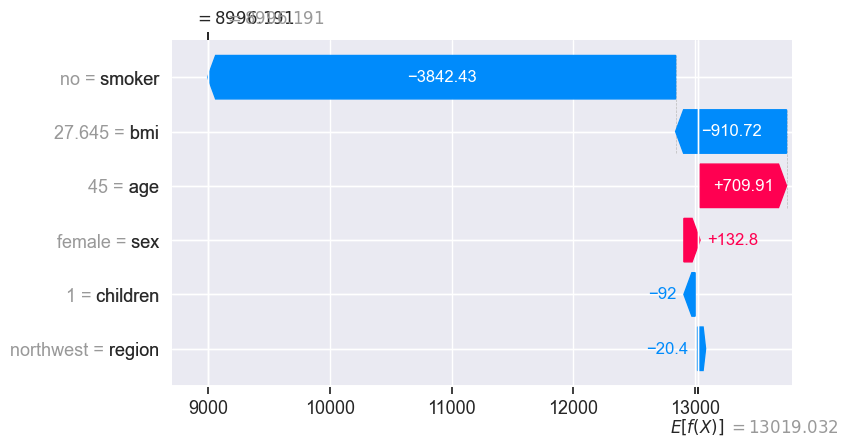

In [60]:
shap.plots.waterfall(shap_values[outlier])

### Insights:  
At the top of the chart is an approximate value of `$8,996`. This is the model's predicted **Charges** for this unique case.  
Under the last x-tick is **_E[f(x)] = `$13,019`. This is the model's "intercept" value. For instance, in the absence of all features,  
`$13,019` becomes the predicted value.  
The waterfall chart above how all six features act on "intercept" value with blue falls decreasing the value while the red falls increase  
the "intercept" value.  
The policyholder's :-  
* "not-a-smoker" status significantly reduced their Charges by `$3,842.43`.
* "over-weight" body mass index also reduced their Charges but by a smaller value than Smoker.
* Children count of "1" and "North-West" region earned them a further drop in Charges by `$92` and `$20.4` respectively.
* Age of "45" earned them an increment in their Charges by `$709.91`
* "female" gender status attracted a further `$132.80` increase in Charges.
   
This is exactly how the model started with an estimated Charge of `$13,019` and ended up at `$8,996`, some `$4,023` decrease
in the average prediction. In this case, the most significant reduction was due to the policyholder's smoking status, while  
the other features had minor effects on the final prediction.

## Residual Analysis

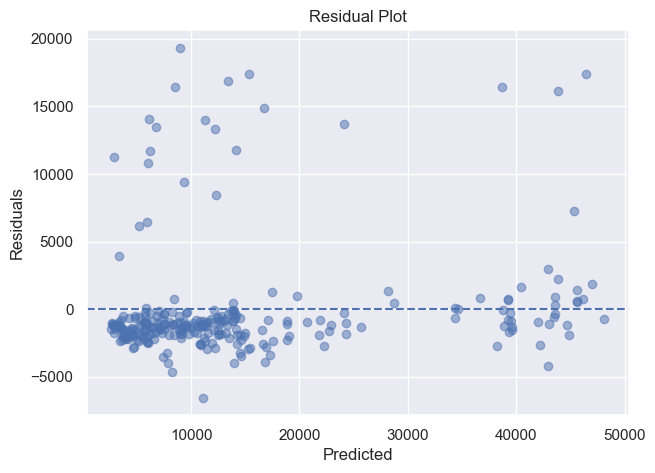

In [61]:
# Create a plot of residuals
plt.figure(figsize=(7,5))
plt.scatter(
    predictions,
    residuals,
    alpha= 0.5
)

plt.axhline(
    0,
    linestyle= "--"
)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Insights:  
* The proportion of data points closer to zero are far more than the proportion of data points away.
  This means that a large proportion of predictions made by the best model (in this case, XGBoost Regressor)
  are very close to the actual Charges values. This shows that most predictions are done with little errors.
* A number of extreme positive values can be seen in the chart above, showing that the model under-predicted some values.
  However, the very large number of data points in the negative axis shows that when the model over-estimates, it
  does not miss by as much as it under-estimates.


## Predicted vs Actual Plot

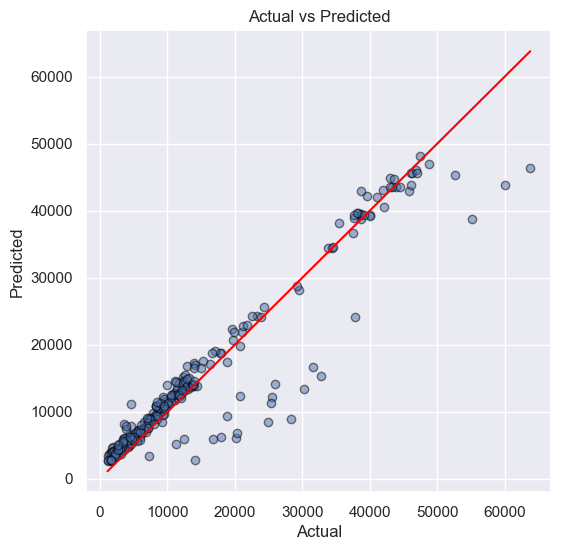

In [62]:
# Create Predicted vs Actual plot  
plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    predictions,
    alpha= 0.5,
    edgecolors= "black"
)
# Line where Predicted = Actual
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color= "red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

### Insights:  
Idealy, it is most preferred for all data points on thr Actual-Predicted chart to lie  
on the Red line as that is the region where `Predicted` = `Actual`. Points above or below  
the Red line indicate points wher Charges were either over-estimated or under-estimated  
respectively.
* Most of the data points lie very close to the Red line which means that XGBRegressor
  accurately predicted most Actual Charges as reflected by its `R2 Score`.
* While the model performs very well for low to mid range Charges vlaues, it does not
  perform well for high range Charges values.